In [1]:
import os
import numpy as np
from PIL import Image


def find_utkface_path(base="/kaggle/input"):
    for root, dirs, files in os.walk(base):
        if any(f.endswith(".jpg") for f in files):
            return root
    return None

image_folder = find_utkface_path()

if image_folder is None:
    raise FileNotFoundError("Dataset introuvable")

print("Dataset trouvé ici :", image_folder)

Dataset trouvé ici : /kaggle/input/datasets/jangedoo/utkface-new/UTKFace


In [2]:
# -------------------------------
# Trouver automatiquement le dossier
# -------------------------------
def find_utkface_path(base="/kaggle/input"):
    for root, dirs, files in os.walk(base):
        if any(f.endswith(".jpg") for f in files):
            return root
    return None

image_folder = find_utkface_path()

if image_folder is None:
    raise FileNotFoundError("Dataset introuvable")

print("Dataset trouvé ici :", image_folder)

# -------------------------------
# Charger les images
# -------------------------------
image_files = [f for f in os.listdir(image_folder) if f.endswith(".jpg")]
print(f"Nombre de fichiers .jpg trouvés : {len(image_files)}")

images = []
labels = []

for file in image_files:
    try:
        parts = file.split("_")
        age = int(parts[0])
        gender = int(parts[1])

        try:
            race = int(parts[2])
        except:
            race = 4

        img = Image.open(os.path.join(image_folder, file))\
                   .convert("L")\
                   .resize((128, 128))

        images.append(np.array(img))
        labels.append([age, gender, race])

    except:
        continue

images = np.array(images)
labels = np.array(labels)

print(f"Images chargées : {len(images)}")
print(f"Shape des images : {images.shape}")

Dataset trouvé ici : /kaggle/input/datasets/jangedoo/utkface-new/UTKFace
Nombre de fichiers .jpg trouvés : 23708
Images chargées : 23708
Shape des images : (23708, 128, 128)


In [3]:
"""## 2. Imports et préparation des données"""

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import(
    Input, Conv2D, SeparableConv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Flatten, Add, Multiply,
    Reshape, Activation, RandomRotation, RandomZoom
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")

# -------------------------------
# Données d'entrée
# -------------------------------
X = images.reshape(images.shape[0], 128, 128, 1)
X = X.astype('float32') / 255.0

print(f"Shape après reshape : {X.shape}")
print(f"X min/max : {X.min():.2f} / {X.max():.2f}")

# -------------------------------
# Labels multi-tâches
# -------------------------------
y_age = labels[:, 0].astype(np.float32) / 100      # régression
y_gender = labels[:, 1].astype(np.float32)    # binaire
y_ethnicity = labels[:, 2].astype(np.int32)   # multi-classes

# -------------------------------
# 1) Train (70%) / Temp (30%)
# -------------------------------
X_train, X_temp, \
y_age_train, y_age_temp, \
y_gender_train, y_gender_temp, \
y_eth_train, y_eth_temp = train_test_split(
    X,
    y_age,
    y_gender,
    y_ethnicity,
    test_size=0.3,
    random_state=42,
    stratify=y_ethnicity
)

# -------------------------------
# 2) Validation (15%) / Test (15%)
# -------------------------------
X_val, X_test, \
y_age_val, y_age_test, \
y_gender_val, y_gender_test, \
y_eth_val, y_eth_test = train_test_split(
    X_temp,
    y_age_temp,
    y_gender_temp,
    y_eth_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_eth_temp
)

# -------------------------------
# Création des versions tournées du test set
# -------------------------------
X_test_90  = np.rot90(X_test, k=1, axes=(1,2))
X_test_180 = np.rot90(X_test, k=2, axes=(1,2))
X_test_270 = np.rot90(X_test, k=3, axes=(1,2))

# -------------------------------
# Encodage ethnicité (softmax)
# -------------------------------
y_eth_train_cat = to_categorical(y_eth_train, num_classes=5)
y_eth_test_cat = to_categorical(y_eth_test, num_classes=5)

y_eth_val_cat   = to_categorical(y_eth_val, num_classes=5)   # MODIFICATION VERSION 7

# -------------------------------
# Class weights (ethnicité)
# -------------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_eth_train),
    y=y_eth_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights (ethnicité) : {class_weight_dict}")

# -------------------------------
# Vérifications
# -------------------------------
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_age_train : {y_age_train.shape}")
print(f"y_gender_train : {y_gender_train.shape}")
print(f"y_eth_train_cat : {y_eth_train_cat.shape}")

2026-03-26 09:37:05.656556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774517825.860618      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774517825.914811      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774517826.401918      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774517826.401949      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774517826.401952      24 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Shape après reshape : (23708, 128, 128, 1)
X min/max : 0.00 / 1.00
Class weights (ethnicité) : {0: np.float64(0.4705131840090729), 1: np.float64(1.0476641414141414), 2: np.float64(1.3806156405990018), 3: np.float64(1.1930265995686555), 4: np.float64(2.7961246840775065)}
X_train : (16595, 128, 128, 1)
X_test  : (3557, 128, 128, 1)
y_age_train : (16595,)
y_gender_train : (16595,)
y_eth_train_cat : (16595, 5)


In [4]:
###### AJOUT DE DATA AUGMENTATION POUR MODEL 5
import tensorflow as tf
from tensorflow.keras import layers, models

def random_90_rotation(x):
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    return tf.image.rot90(x, k)

# data_augmentation = tf.keras.Sequential([
#     layers.Lambda(random_90_rotation),
#     layers.RandomRotation(0.5), # 0.1 vers 0.5 pour rotation de ± 180)
#     layers.RandomZoom(0.1),
#     layers.RandomTranslation(0.05, 0.05),
# ])

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.02, 0.02),
])

#Créer un bloc de prétraitement des images qui va est intégré directement dans le modèle.
#elle génère des versions légèrement modifiées des images pendant l’entraînement
##Sequential => les opérations sont appliquées dans l’ordre
##layers.RandomRotation(0.1) => rotation aléatoire (~ ±36°)
##layers.RandomZoom(0.1), => zoom aléatoire
## déplacement de l'image

I0000 00:00:1774517853.374843      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
# MODEL 6 / 7 --> Version 8
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# -------------------------------
# Entrée
# -------------------------------
input_img = layers.Input(shape=(128, 128, 1))
x = data_augmentation(input_img)  ##MODIFICATION ICI POUR VERSION 7

# -------------------------------
# Bloc CNN 1
# -------------------------------
x = layers.Conv2D(32, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# -------------------------------
# Bloc CNN 2
# -------------------------------
x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# -------------------------------
# Bloc CNN 3
# -------------------------------
x = layers.Conv2D(128, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# -------------------------------
# Bloc CNN 4 (profond)
# -------------------------------
x = layers.Conv2D(256, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

# -------------------------------
# Global Pooling
# -------------------------------
x = layers.GlobalAveragePooling2D()(x)


# -------------------------------
# Features partagées
# -------------------------------
shared = layers.Dense(256, activation='relu')(x)
shared = layers.BatchNormalization()(shared)
shared = layers.Dropout(0.4)(shared)

# ===============================
# BRANCHE AGE (régression)
# ===============================
age_branch = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(shared)
age_branch = Dropout(0.4)(age_branch)

age_branch = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(age_branch)
age_output = Dense(1, activation='linear', name='age')(age_branch)


# ===============================
# BRANCHE GENDER (classification simple)
# ===============================
gender_branch = layers.Dense(128, activation='relu')(shared)
gender_branch = layers.Dropout(0.3)(gender_branch)
gender_output = layers.Dense(1, activation='sigmoid', name='gender')(gender_branch)

# ===============================
# BRANCHE ETHNICITY (plus difficile → plus profond)
# ===============================
eth_branch = layers.Dense(256, activation='relu')(shared)
eth_branch = layers.Dense(128, activation='relu')(eth_branch)
eth_branch = layers.Dropout(0.5)(eth_branch)
ethnicity_output = layers.Dense(5, activation='softmax', name='ethnicity')(eth_branch)




# -------------------------------
# Modèle final
# -------------------------------
model = models.Model(
    inputs=input_img,
    outputs=[age_output, gender_output, ethnicity_output]
)

In [6]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5),
    # optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    # optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5),
    # optimizer=Adam(1e-4),
    loss={
        "age": tf.keras.losses.Huber(delta=8.0),
        "gender": "binary_crossentropy",
        "ethnicity": "categorical_crossentropy"
    },
    loss_weights = {
    "age": 0.7,
    "gender": 0.8,
    "ethnicity": 1.0
},
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "ethnicity": ["accuracy"]
    }
)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,              # arrête si ça n'améliore plus
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # divise le LR
    patience=5,               # après 4 epochs sans progrès
    min_lr=1e-6,
    verbose=1
)

In [8]:
history = model.fit(
    X_train,
    {
        'age': y_age_train,
        'gender': y_gender_train,
        'ethnicity': y_eth_train_cat
    },
    validation_data=(
        X_val,  # utiliser X_val plutôt que X_test pour validation
        {
            'age': y_age_val,
            'gender': y_gender_val,
            'ethnicity': y_eth_val_cat
        }
    ),
    epochs=80,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],  #AJOUTER APRES VERSION 7.1
    shuffle=True
)

print("\n===== TEST ORIGINAL =====")
model.evaluate(X_test, {
    'age': y_age_test,
    'gender': y_gender_test,
    'ethnicity': y_eth_test_cat
})

print("\n===== TEST 90° =====")
model.evaluate(X_test_90, {
    'age': y_age_test,
    'gender': y_gender_test,
    'ethnicity': y_eth_test_cat
})

print("\n===== TEST 180° =====")
model.evaluate(X_test_180, {
    'age': y_age_test,
    'gender': y_gender_test,
    'ethnicity': y_eth_test_cat
})

Epoch 1/80


I0000 00:00:1774517864.914792      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


130/130 ━━━━━━━━━━━━━━━━━━━━ 27s 131ms/step - age_loss: 0.4420 - age_mae: 0.7011 - ethnicity_accuracy: 0.3011 - ethnicity_loss: 1.7113 - gender_accuracy: 0.5582 - gender_loss: 0.7683 - loss: 2.6609 - val_age_loss: 0.0792 - val_age_mae: 0.3457 - val_ethnicity_accuracy: 0.4252 - val_ethnicity_loss: 1.5219 - val_gender_accuracy: 0.5354 - val_gender_loss: 0.6913 - val_loss: 2.1559 - learning_rate: 5.0000e-05
Epoch 2/80
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - age_loss: 0.1646 - age_mae: 0.4399 - ethnicity_accuracy: 0.4207 - ethnicity_loss: 1.4578 - gender_accuracy: 0.6254 - gender_loss: 0.6829 - loss: 2.1445 - val_age_loss: 0.0476 - val_age_mae: 0.2513 - val_ethnicity_accuracy: 0.4035 - val_ethnicity_loss: 1.5149 - val_gender_accuracy: 0.5307 - val_gender_loss: 0.6892 - val_loss: 2.1253 - learning_rate: 5.0000e-05
Epoch 3/80
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - age_loss: 0.1261 - age_mae: 0.3896 - ethnicity_accuracy: 0.4541 - ethnicity_loss: 1.3866 - gender_accuracy: 0.6443 -

[1.972013235092163,
 0.017494909465312958,
 0.7782723307609558,
 1.3213905096054077,
 0.14173899590969086,
 0.5324711799621582,
 0.5752038359642029]

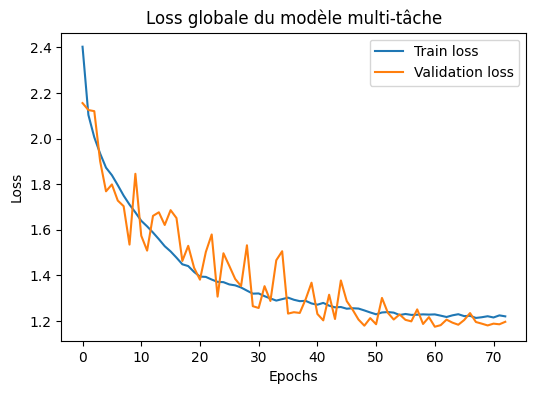

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss globale du modèle multi-tâche')
plt.legend()
plt.show()

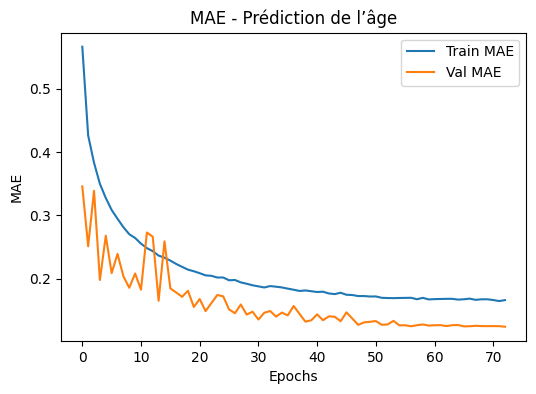

In [10]:
plt.figure(figsize=(6,4))
plt.plot(history.history['age_mae'], label='Train MAE')
plt.plot(history.history['val_age_mae'], label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('MAE - Prédiction de l’âge')
plt.legend()
plt.show()
plt.savefig("/kaggle/working/age_mae.png")
plt.close()

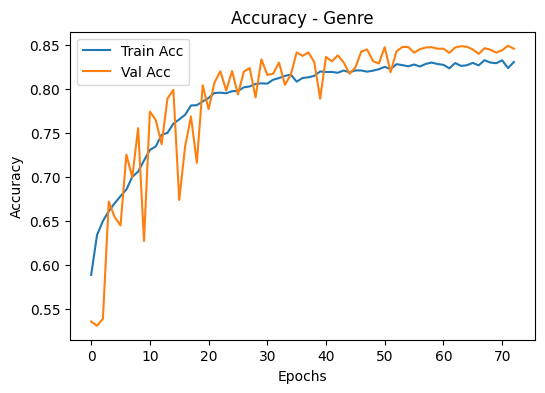

In [11]:
plt.figure(figsize=(6,4))
plt.plot(history.history['gender_accuracy'], label='Train Acc')
plt.plot(history.history['val_gender_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy - Genre')
plt.legend()
plt.show()

plt.savefig("/kaggle/working/gender_accuracy.png")
plt.close()

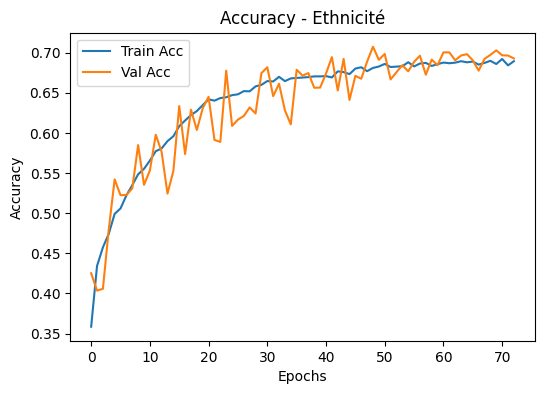

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history.history['ethnicity_accuracy'], label='Train Acc')
plt.plot(history.history['val_ethnicity_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy - Ethnicité')
plt.legend()
plt.show()

plt.savefig("/kaggle/working/ethnicity_accuracy.png")
plt.close()

In [13]:
#Sauvegarder les métriques numériques (CSV → Output): metrics_training.csv
import pandas as pd

metrics_df = pd.DataFrame(history.history)
metrics_df.to_csv("/kaggle/working/metrics_training.csv", index=False)

In [14]:
#Sauvegarder l’évaluation finale du modèle (TXT): test_metrics.txt
results = model.evaluate(
    X_test,
    {
        'age': y_age_test,
        'gender': y_gender_test,
        'ethnicity': y_eth_test_cat
    },
    verbose=0
)

with open("/kaggle/working/test_metrics.txt", "w") as f:
    for name, value in zip(model.metrics_names, results):
        f.write(f"{name}: {value:.4f}\n")

In [15]:
results = model.evaluate(
    X_test,
    {
        'age': y_age_test,
        'gender': y_gender_test,
        'ethnicity': y_eth_test_cat
    },
    verbose=1
)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - age_loss: 0.0145 - age_mae: 0.1284 - ethnicity_accuracy: 0.6886 - ethnicity_loss: 0.8524 - gender_accuracy: 0.8342 - gender_loss: 0.3628 - loss: 1.1719
loss: 1.1696
compile_metrics: 0.0146
age_loss: 0.3701
gender_loss: 0.8538
ethnicity_loss: 0.1289


In [16]:
# model.save("/kaggle/working/model_saved")
model.export("/kaggle/working/model_saved")

INFO:tensorflow:Assets written to: /kaggle/working/model_saved/assets


INFO:tensorflow:Assets written to: /kaggle/working/model_saved/assets


Saved artifact at '/kaggle/working/model_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)]
Captures:
  140409187993168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187994128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187994896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187994320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187994512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187998544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187998928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187996048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140409187997392: Tens

In [17]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("/kaggle/working/model_saved")
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("/kaggle/working/model.tflite", "wb") as f:
    f.write(tflite_model)

print("Conversion OK ✅")

W0000 00:00:1774518979.873408      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1774518979.873459      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1774518979.912760      24 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
loc(callsite(callsite(fused["StatelessRandomGetKeyCounter:", "functional_1_1/sequential_1/random_rotation_1/stateless_random_uniform/StatelessRandomGetKeyCounter@__inference___call___536539"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___536754"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.StatelessRandomGetKeyCounter' op is neither a custom op nor a flex op
loc(callsite(callsite(fused["StatelessRandomGetKeyCounter:", "functional_1_1/sequential_1/random_translation_1/stateless_random_uniform_1/StatelessRandomGetKeyCounter@__inference___call___536539"] at fused["StatefulPartitionedCall:

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["StatelessRandomGetKeyCounter:", "functional_1_1/sequential_1/random_rotation_1/stateless_random_uniform/StatelessRandomGetKeyCounter@__inference___call___536539"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___536754"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.StatelessRandomGetKeyCounter' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["StatelessRandomGetKeyCounter:", "functional_1_1/sequential_1/random_rotation_1/stateless_random_uniform/StatelessRandomGetKeyCounter@__inference___call___536539"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___536754"]) at fused["StatefulPartitionedCall:", "StatefulPartitioned